# Allen: quiet-calibrated state and conditional response prediction

## tl;dr
- positive: quiet-selected baseline last_bin; later recovery RMSE (uV): none 112.94, constant 133.17, depression 132.99, facilitation 131.93.
- negative: quiet-selected baseline local_level; later recovery RMSE (uV): none 73.96, constant 74.46, depression 74.29, facilitation 74.93.

## Context & Methods
This retrospective analysis asks whether activity-dependent efficacy adds useful
prediction after a voltage state is estimated from earlier available observations.
It follows the baseline sensitivity in the previous waveform analysis. Data and
later outcomes were previously inspected: this is not blind validation.

### Key Assumptions
- Calibrate only command-free 0.08–0.53 s voltage in sweeps 37–46. Check later
  sweeps 47–56 separately. Both targets and the source have stored zero command;
  the source has no detected AP in this quiet interval. Unobserved inputs remain.
- Candidate state models: last bin, last four bins, local level, local linear trend.
  Bin width is 0.5 ms. State-model ratios are fitted by quiet innovation likelihood;
  the family is chosen by training quiet mean-voltage prediction at 4–10 ms.
- Linear Gaussian state models are statistical candidates, not identified membrane
  equations. Descriptive innovation and coverage diagnostics check their limits.
- Response prediction can observe preceding inter-response target voltage. Every
  artifact interval and every scored spike+[2,8] ms response is excluded from state
  updates. This observation budget differs from earlier open-loop waveform work.
- Fit only initial eight responses of sweeps 37–46. Use the same baseline operator
  and the same kernel/history candidate grid for fixed, depression and facilitation.
  Kernel tails are subtracted consistently from the state estimate. No free offset.
- Repeated same-cell sweeps and overlapping forecast windows are not independent
  animals. Negative target means no reported synapse, not an inhibitory connection.

## Data


In [1]:
import hashlib,json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image,display
root = next(p for p in [Path.cwd(),*Path.cwd().parents]
            if (p/'verify/Q-NPF-04/allen_synphys/recovery_causal_baseline_result.json').exists())
folder = root/'verify/Q-NPF-04/allen_synphys'
result_path = folder/'recovery_causal_baseline_result.json'
result = json.loads(result_path.read_text(encoding='utf-8'))
def digest(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream,'sha256').hexdigest()
assert digest(folder/'recovery_causal_baseline.py') == result['source_sha256']
assert digest(root/'tests/test_recovery_causal_baseline.py') == result['test_sha256']
assert digest(root/result['provenance']['parent_path']) == result['provenance']['parent_sha256']
assert digest(folder/'recovery_waveform_prediction.py') == result['provenance']['parent_source_sha256']
assert digest(folder/'ic_command_context_result.json') == result['provenance']['command_context_sha256']
assert digest(root/result['arrays']['path']) == result['arrays']['sha256']
with np.load(root/result['arrays']['path'],allow_pickle=False) as archive:
    arrays = {k:archive[k] for k in archive.files}
eligible = result['provenance']['reused_eligibility']
print('Result SHA256:',digest(result_path))
print('Included target-sweeps:',sum(r['included'] for r in eligible),'/',len(eligible))
for row in eligible:
    if not row['included']:
        print('Excluded:',row['sweep'],row['target'],'; '.join(row['reasons']))
print('Verified input reuse; no download. Previous open-loop RMSE is not a matched comparator.')


Result SHA256: 7576569de951b24c15a6c1abb7c7017c769c781380c244015177cf5621065a3f
Included target-sweeps: 43 / 50
Excluded: 32 negative target_command_unobserved: Uncached block 627507200
Excluded: 33 negative target_command_unobserved: Uncached block 636223488
Excluded: 34 negative target_command_unobserved: Uncached block 644022272
Excluded: 35 positive source_full_gap_unobserved: Uncached block 745209856
Excluded: 35 negative source_full_gap_unobserved: Uncached block 745209856; target_command_unobserved: Uncached block 664338432
Excluded: 36 positive source_full_gap_unobserved: Uncached block 747241472; target_has_own_nonzero_command
Excluded: 36 negative source_full_gap_unobserved: Uncached block 747241472; target_command_unobserved: Uncached block 694157312
Verified input reuse; no download. Previous open-loop RMSE is not a matched comparator.


## Results

### Quiet forecasts and statistical calibration
Forecast origins recur every 10 ms after 100 ms warmup. Near and far horizons
average 4–10 ms and 20–26 ms after each origin. RMSE is recomputed below from
saved predictions and observed bin values. Coverage is descriptive, not a test
that the noise law is true. Each panel has its own y scale, starting at zero.


positive selected: {'kind': 'last_bin', 'training_near_rmse_uV': 140.5997935332546}
last_bin training near 140.6 uV coverage not modelled
last_bin temporal near 179.728 uV coverage not modelled
last_bin training far 263.926 uV coverage not modelled
last_bin temporal far 330.622 uV coverage not modelled
mean2ms training near 147.037 uV coverage not modelled
mean2ms temporal near 187.538 uV coverage not modelled
mean2ms training far 266.131 uV coverage not modelled
mean2ms temporal far 332.817 uV coverage not modelled
local_level training near 140.6 uV coverage 0.903125
local_level temporal near 179.729 uV coverage 0.85
local_level training far 263.926 uV coverage 0.825
local_level temporal far 330.622 uV coverage 0.771875
Innovation: {'model': 'local_level', 'cohort': 'training', 'horizon': 'one_bin_innovation', 'sweeps': 10, 'standardized_rms': 1.0, 'mean_lag1_correlation': 0.19122297585865505}
Innovation: {'model': 'local_level', 'cohort': 'temporal', 'horizon': 'one_bin_innovation', 

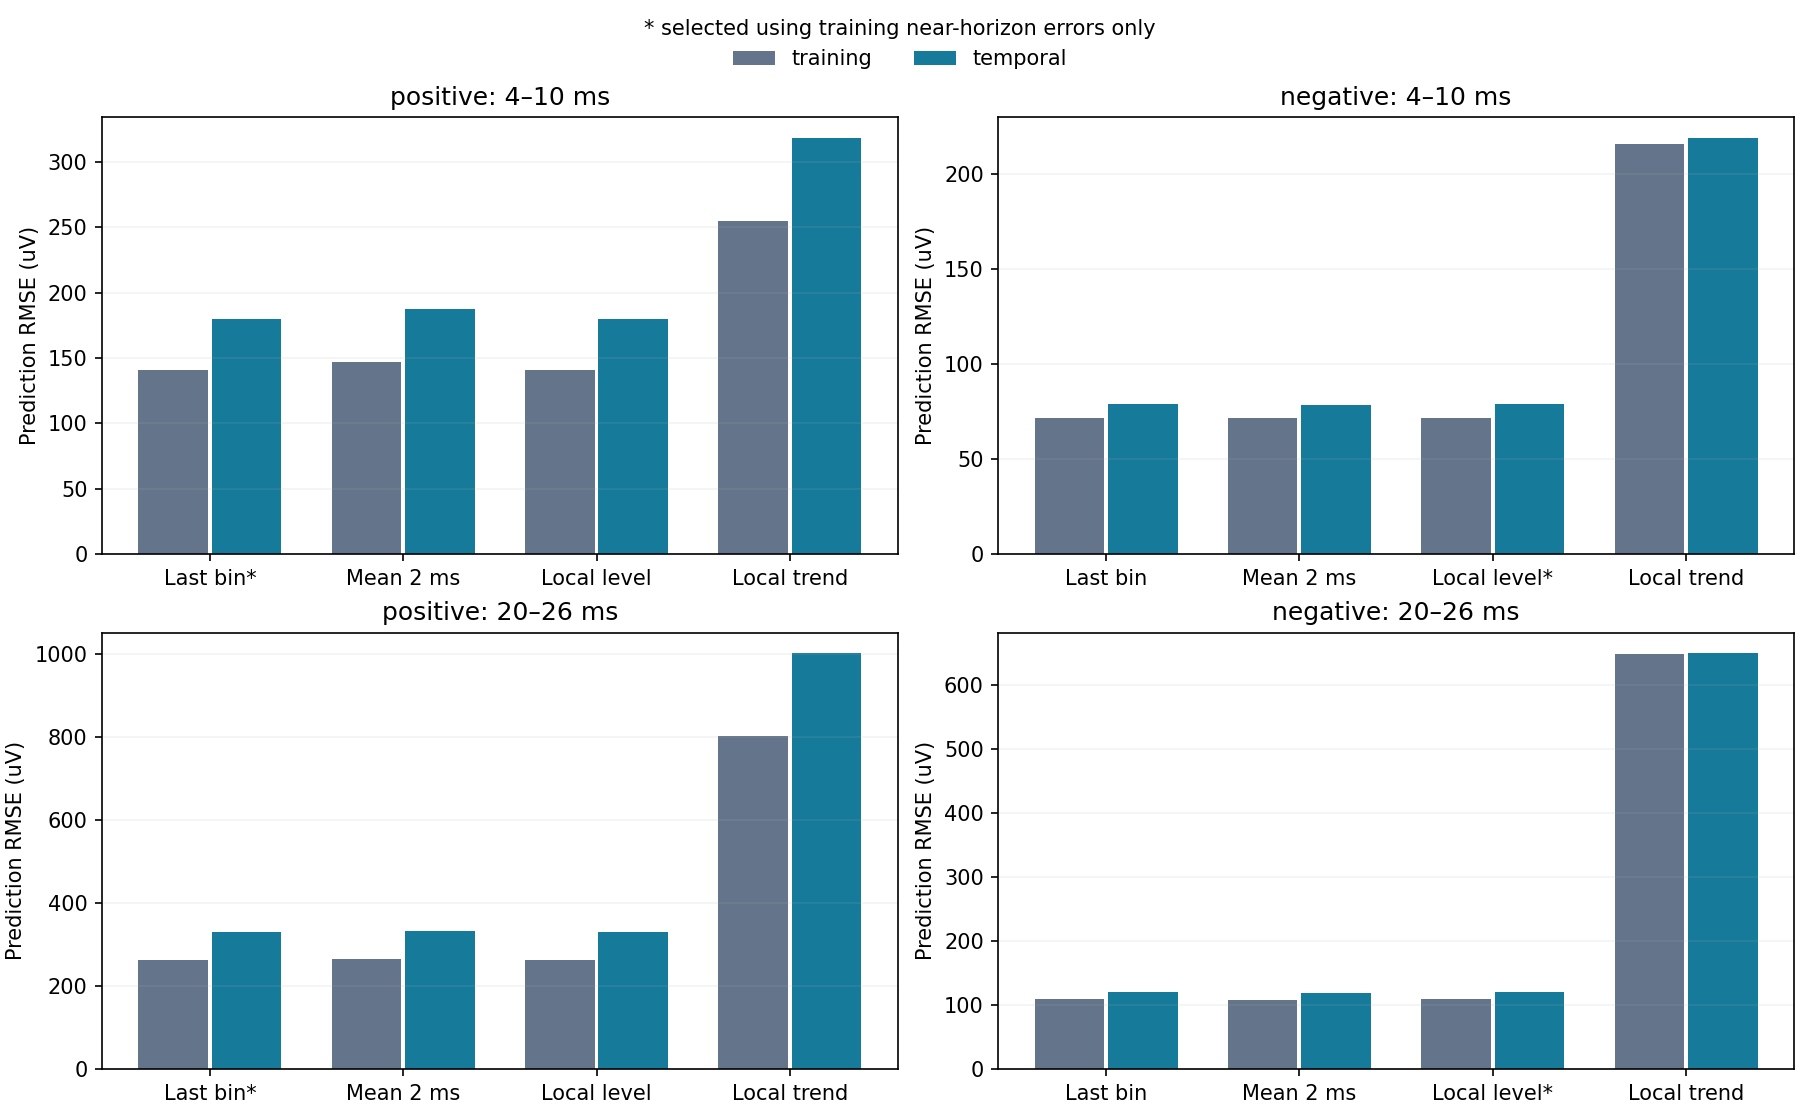

In [2]:
origins = np.array(result['quiet_design']['origins_bins'])
for target in ('positive','negative'):
    print(target,'selected:',result['calibration'][target]['selected'])
    observed = arrays[target+'_quiet_observed']
    for name,offsets in result['quiet_design']['horizon_offsets'].items():
        truth = np.stack([observed[:,i+np.array(offsets)].mean(axis=1) for i in origins],axis=1)
        np.testing.assert_allclose(truth,arrays[target+'_quiet_truth_'+name],rtol=1e-12)
    for row in result['quiet_summary']:
        if row['target']!=target:
            continue
        if row['horizon']=='one_bin_innovation':
            print('Innovation:',{k:v for k,v in row.items() if k!='target'})
            continue
        sl = slice(0,10) if row['cohort']=='training' else slice(10,20)
        prediction = arrays[target+'_quiet_'+row['model']+'_prediction_'+row['horizon']][sl]
        truth = arrays[target+'_quiet_truth_'+row['horizon']][sl]
        rmse = np.sqrt(np.mean((prediction-truth)**2))
        np.testing.assert_allclose(rmse,row['rmse_uV'],rtol=1e-12)
        print(row['model'],row['cohort'],row['horizon'],round(rmse,3),'uV',
              'coverage',row.get('coverage_1_96sd','not modelled'))
fig,axes = plt.subplots(2,2,figsize=(12,7.4),layout='constrained')
kinds = ('last_bin','mean2ms','local_level','local_trend')
labels = ('Last bin','Mean 2 ms','Local level','Local trend')
for col,target in enumerate(('positive','negative')):
    for row_index,horizon in enumerate(('near','far')):
        ax = axes[row_index,col]
        for shift,cohort,color in ((-.19,'training','#64748B'),(.19,'temporal','#167A9B')):
            values = [next(r['rmse_uV'] for r in result['quiet_summary'] if
                r['target']==target and r['horizon']==horizon and r['model']==kind and r['cohort']==cohort) for kind in kinds]
            ax.bar(np.arange(4)+shift,values,width=.36,color=color,label=cohort)
        selected = result['calibration'][target]['selected']['kind']
        ax.set_xticks(np.arange(4),[label+('*' if kind==selected else '') for kind,label in zip(kinds,labels)])
        ax.set(title=f'{target}: '+('4–10 ms' if horizon=='near' else '20–26 ms'),ylabel='Prediction RMSE (uV)')
        ax.set_ylim(bottom=0)
        ax.grid(axis='y',alpha=.15)
handles,labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='outside upper center',ncol=2,frameon=False,title='* selected using training near-horizon errors only')
fig.savefig(folder/'figures/recovery_causal_quiet.png',dpi=150)
display(Image(filename=str(folder/'figures/recovery_causal_quiet.png')))
plt.close(fig)


### Response predictions under a common causal observation budget
M averages complete 0.5 ms bins in each scored response; B predicts its baseline
from preceding available bins. With candidate kernel-history signal x, prediction
is B y + A (M − B) x. This equals B(y − A x) + A M x: the candidate's earlier tails
are removed before predicting the baseline. All models share B; A is nonnegative.
The null predicts only B y. No scored response enters its own B prediction.


In [3]:
for row in result['per_sweep']:
    key = str(row['sweep'])+'_'+row['target']+'_'+row['baseline']
    sl = slice(0,8) if row['region']=='initial' else slice(8,12)
    error = arrays[key+'_prediction_'+row['method']][sl]-arrays[key+'_observed'][sl]
    np.testing.assert_allclose(np.mean(error**2),row['mse_uV2'],rtol=1e-12)
    np.testing.assert_allclose(np.mean(error),row['bias_uV'],rtol=1e-12,atol=1e-12)
print('All',len(result['per_sweep']),'per-sweep MSE and bias rows reproduced from arrays.')
cohorts = dict(training=set(range(37,47)),temporal=set(range(47,57)),variable_gap=set(range(32,37)))
for row in result['summary']:
    matched = [r for r in result['per_sweep'] if all(r[k]==row[k] for k in ('target','baseline','region','method'))
               and r['sweep'] in cohorts[row['cohort']]]
    np.testing.assert_allclose(np.sqrt(np.mean([r['mse_uV2'] for r in matched])),row['rmse_uV'],rtol=1e-12)
    assert len(matched)==row['sweeps']
    if row['cohort']=='temporal':
        comparison = row['comparators']['constant']
        print(row['target'],row['baseline'],row['region'],row['method'],round(row['rmse_uV'],3),'uV',
              'improved vs fixed',comparison['improved_sweeps'],'/',row['sweeps'])
print('Variable-gap predictions (positive only; three eligible sweeps):')
for row in result['summary']:
    if row['cohort']=='variable_gap' and row['region']=='recovery':
        print(row['baseline'],row['method'],round(row['rmse_uV'],3),'uV')
print('Fitted response parameters:',json.dumps(result['models'],indent=2))


All 688 per-sweep MSE and bias rows reproduced from arrays.
positive selected initial none 223.315 uV improved vs fixed 4 / 10
positive selected initial constant 217.232 uV improved vs fixed 0 / 10
positive selected initial depression 216.751 uV improved vs fixed 7 / 10
positive selected initial facilitation 217.131 uV improved vs fixed 4 / 10
positive selected recovery none 112.939 uV improved vs fixed 6 / 10
positive selected recovery constant 133.166 uV improved vs fixed 0 / 10
positive selected recovery depression 132.993 uV improved vs fixed 7 / 10
positive selected recovery facilitation 131.932 uV improved vs fixed 8 / 10
positive last_bin initial none 223.315 uV improved vs fixed 4 / 10
positive last_bin initial constant 217.232 uV improved vs fixed 0 / 10
positive last_bin initial depression 216.751 uV improved vs fixed 7 / 10
positive last_bin initial facilitation 217.131 uV improved vs fixed 4 / 10
positive last_bin recovery none 112.939 uV improved vs fixed 6 / 10
positive l

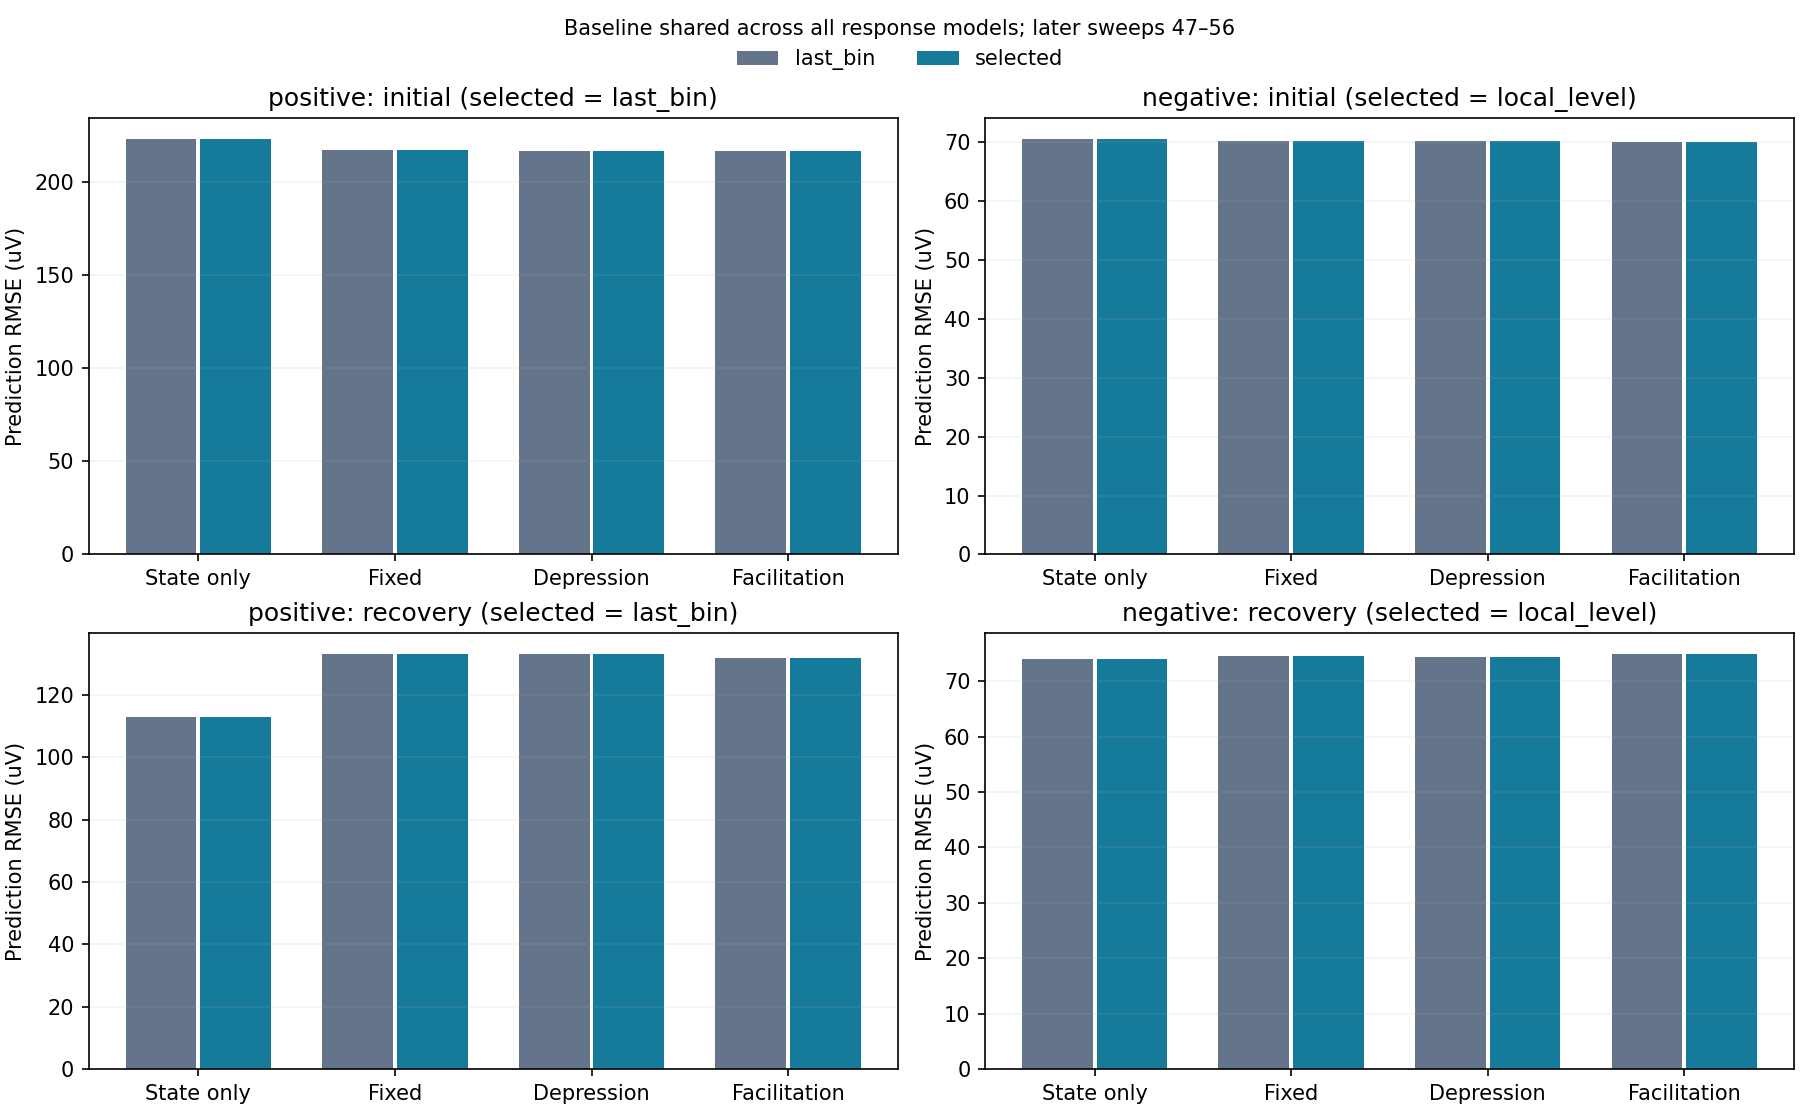

In [4]:
fig,axes = plt.subplots(2,2,figsize=(12,7.4),layout='constrained')
methods = ('none','constant','depression','facilitation')
for col,target in enumerate(('positive','negative')):
    for row_index,region in enumerate(('initial','recovery')):
        ax = axes[row_index,col]
        for shift,baseline,color in ((-.19,'last_bin','#64748B'),(.19,'selected','#167A9B')):
            values = [next(r['rmse_uV'] for r in result['summary'] if r['target']==target and
                r['region']==region and r['baseline']==baseline and r['cohort']=='temporal' and r['method']==method) for method in methods]
            ax.bar(np.arange(4)+shift,values,width=.36,color=color,label=baseline)
        selected = result['calibration'][target]['selected']['kind']
        ax.set_xticks(np.arange(4),('State only','Fixed','Depression','Facilitation'))
        ax.set(title=f'{target}: {region} (selected = {selected})',ylabel='Prediction RMSE (uV)')
        ax.set_ylim(bottom=0)
        ax.grid(axis='y',alpha=.15)
handles,labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles,labels,loc='outside upper center',ncol=2,frameon=False,title='Baseline shared across all response models; later sweeps 47–56')
fig.savefig(folder/'figures/recovery_causal_response.png',dpi=150)
display(Image(filename=str(folder/'figures/recovery_causal_response.png')))
plt.close(fig)


## Interpretation & Next Steps
Quiet forecast improvements establish only a predictive statistical state in this
recording. They do not identify RC parameters, a unique physical delay or plasticity.
An efficacy model must improve excluded responses beyond the common state model;
even then its mechanism requires independent conditions and identified inputs.
Do not turn an unverified Gaussian residual law into a calibrated Fisher metric.
The comparison uses short conditional response means, not the earlier open-loop
whole waveform. Values across those observation budgets are not performance gains.

## Reproducibility
Input/source/test/array hashes are checked above. Four code cells execute in order.
The companion recomputes quiet RMSE, all response MSE/bias and grouped RMSE from
saved arrays. No fits, downloads or overwrites of earlier outputs occur here.
